### 📌 Introdução ao problema

## <font color=yellow>Detecção de Fraudes em Transações com Cartão de Crédito</font>

As fraudes em transações financeiras são um grande desafio para instituições bancárias e empresas de pagamento. A cada ano, milhões de reais são perdidos devido a atividades fraudulentas, prejudicando tanto os consumidores quanto o mercado financeiro. Neste projeto, buscamos desenvolver uma `solução` baseada em dados para detectar e prevenir fraudes em transações com cartão de crédito.


Os dados desempenham um papel essencial nesse processo, pois registram informações detalhadas sobre cada transação, como valores, horários e padrões de comportamento dos clientes. Através da análise desses dados, podemos `identificar comportamentos suspeitos` e diferenciar transações legítimas de tentativas de fraude. Modelos de machine learning são particularmente úteis nesse contexto, pois conseguem aprender padrões e prever possíveis fraudes com base em características históricas.


No entanto, a detecção de fraudes apresenta desafios significativos:

* O principal deles é o `desequilíbrio de classes`, já que a grande maioria das transações é legítima, enquanto as fraudulentas representam uma fração muito pequena dos dados. Isso pode dificultar o aprendizado dos modelos e exigir técnicas avançadas para garantir que as fraudes sejam detectadas sem aumentar a taxa de falsos positivos. Além disso, os criminosos estão constantemente inovando suas táticas, tornando necessário o aprimoramento contínuo dos métodos de detecção.
* Outro desafio importante é a `necessidade de detecção em tempo real`. Muitas transações fraudulentas ocorrem em segundos, e um atraso na identificação pode significar um grande prejuízo. Isso exige que os modelos sejam rápidos e eficientes, garantindo uma resposta imediata para prevenir perdas financeiras.


Com este projeto, nosso objetivo é desenvolver uma abordagem eficiente para a detecção de fraudes, utilizando técnicas de análise de dados e aprendizado de máquina. A partir de um conjunto de dados reais de transações com cartão de crédito, exploraremos padrões, aplicaremos modelos estatísticos e avaliaremos sua eficácia na identificação de fraudes.

In [1]:
### Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, chi2

In [4]:
### Carregamento dos dados
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
### Análise exploratória dos dados
# Verificando valores nulos
df.isnull().sum()

# Eliminando valores duplicados
df = df.drop_duplicates()

# Verificando se os valores duplicados foram eliminados
df.duplicated().sum()

# Verificando valores outliers
df.describe()

print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

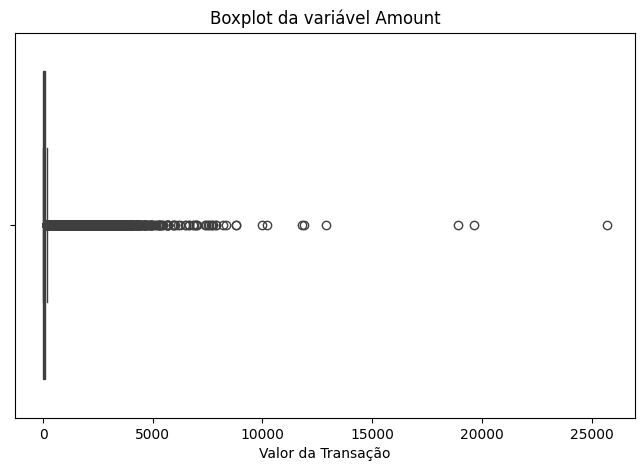

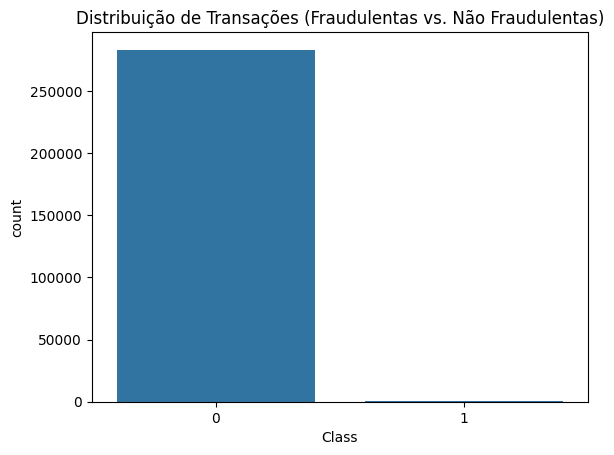

In [6]:
### Distribuição da variável alvo
# Visualizando valores discrepantes
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Amount"])
plt.title("Boxplot da variável Amount")
plt.xlabel("Valor da Transação")
plt.show()

# Separar as transações fraudulentas e não fraudulentas
fraudulentas = df[df["Class"] == 1]
nao_fraudulentas = df[df["Class"] == 0]

# Estatísticas descritivas para cada grupo
stats_fraud = fraudulentas.describe()
stats_nao_fraud = nao_fraudulentas.describe()

stats_fraud, stats_nao_fraud

sns.countplot(x=df['Class'])
plt.title("Distribuição de Transações (Fraudulentas vs. Não Fraudulentas)")
plt.show()

###Os histogramas a seguir mostram a distribuição das transações fraudulentas e não fraudulentas. Isso nos ajuda a identificar padrões nos dados, visualizar a dispersão e detectar possíveis outliers antes de prosseguir para a modelagem.

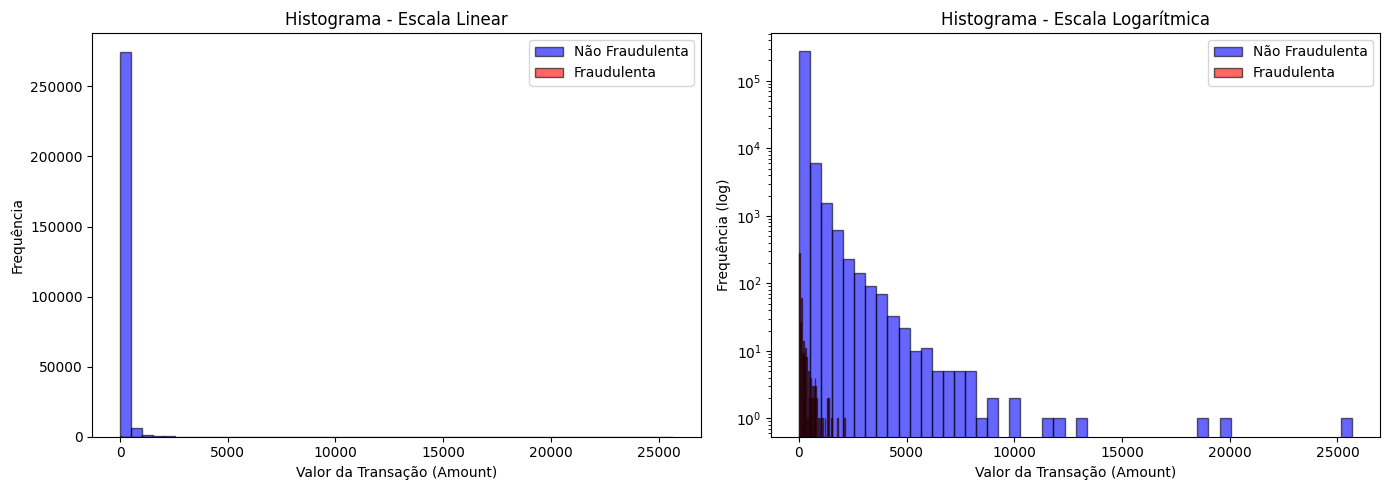

In [7]:
# Criar histogramas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma com escala linear para a coluna 'Amount'
axes[0].hist(nao_fraudulentas['Amount'], bins=50, alpha=0.6, label="Não Fraudulenta", color="blue", edgecolor="black")
axes[0].hist(fraudulentas['Amount'], bins=50, alpha=0.6, label="Fraudulenta", color="red", edgecolor="black")
axes[0].set_title("Histograma - Escala Linear")
axes[0].set_xlabel("Valor da Transação (Amount)")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Histograma com escala logarítmica para a coluna 'Amount'
axes[1].hist(nao_fraudulentas['Amount'], bins=50, alpha=0.6, label="Não Fraudulenta", color="blue", edgecolor="black", log=True)
axes[1].hist(fraudulentas['Amount'], bins=50, alpha=0.6, label="Fraudulenta", color="red", edgecolor="black", log=True)
axes[1].set_title("Histograma - Escala Logarítmica")
axes[1].set_xlabel("Valor da Transação (Amount)")
axes[1].set_ylabel("Frequência (log)")
axes[1].legend()

plt.tight_layout()
plt.show()

Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64


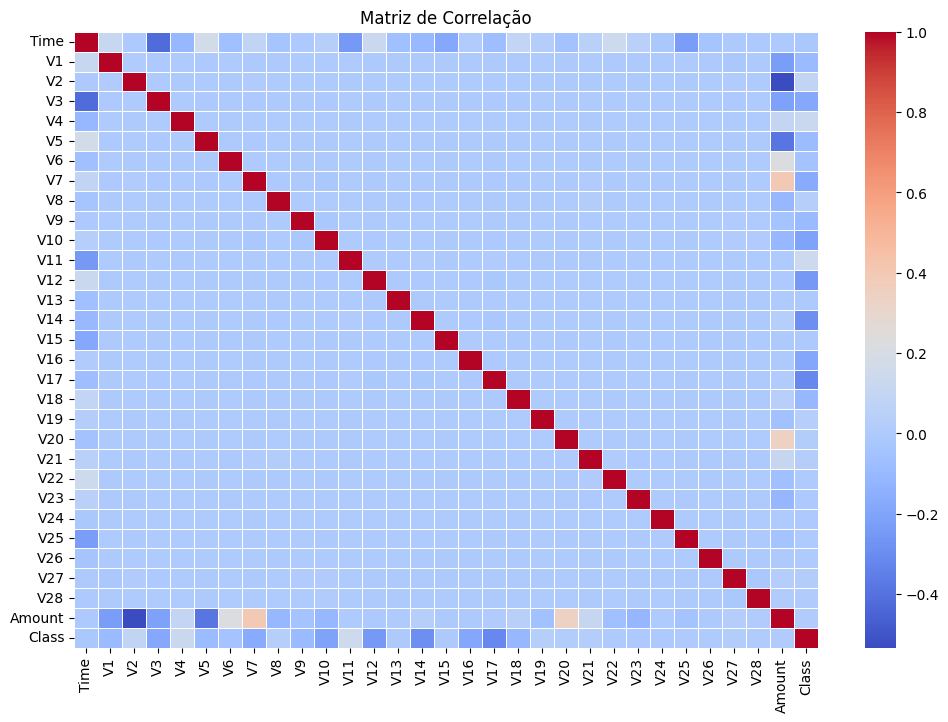

In [8]:
### Correlação das variáveis com a variável alvo
# Calcula a matriz de correlação
correlation_matrix = df.corr()

# Filtra as correlações com a variável 'Class'
correlation_with_class = correlation_matrix["Class"].sort_values(ascending=False)

# Exibe as 10 variáveis mais correlacionadas com 'Class'
print(correlation_with_class.head(10))

# Visualiza a matriz de correlação com um heatmap
correlation_matrix = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlação")
plt.show()

### 📌 Justificativa

## <font color=yellow>Variáveis mais relevantes</font>

Para a construção do nosso modelo de detecção de fraudes em transações de cartão de crédito, analisamos a correlação entre as variáveis e a variável alvo (`Class`). Identificamos que algumas variáveis possuem maior influência na distinção entre transações legítimas e fraudulentas.  

As variáveis com maior correlação positiva ou negativa com a variável `Class` foram **V17, V14, V12, V10 e V4**. Isso indica que elas apresentam padrões que podem ser explorados pelo modelo para diferenciar transações fraudulentas das não fraudulentas.  

A justificativa para a escolha dessas variáveis inclui:  
* **Maior correlação com a variável alvo**: Essas variáveis mostraram valores mais altos de correlação, o que sugere que podem ter impacto significativo na previsão.  
* **Relevância prática para o problema**: Embora os nomes das variáveis estejam anonimizados, o fato de apresentarem altos valores absolutos de correlação sugere que podem representar características críticas de uma transação, como valores incomuns, padrões de gasto anômalos ou outras particularidades associadas a fraudes.  
* **Evitar variáveis irrelevantes**: Variáveis com correlação muito próxima de zero não contribuem para a diferenciação entre transações fraudulentas e legítimas e, portanto, foram descartadas.  

Essa seleção ajudará nosso modelo a ser mais eficiente, reduzindo o ruído e focando nas informações mais úteis para detectar fraudes.  


In [9]:
### Seleção das variáveis mais relevantes
# Baseando-se na análise de correlação e na importância das features
features_relevantes = ['V4', 'V10', 'V12', 'V14', 'V17']
X = df[features_relevantes]
y = df['Class']

# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronização das variáveis
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Treinamento do modelo
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Avaliação do modelo
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print("Acurácia:", accuracy_score(y_test, y_pred))

# Verificação da importância das variáveis
feature_importances = pd.Series(clf.feature_importances_, index=features_relevantes).sort_values(ascending=False)
print("Importância das Features:")
print(feature_importances)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.72      0.80        95

    accuracy                           1.00     56746
   macro avg       0.95      0.86      0.90     56746
weighted avg       1.00      1.00      1.00     56746

Acurácia: 0.9993832164381631
Importância das Features:
V17    0.317682
V12    0.251269
V14    0.200318
V10    0.147724
V4     0.083007
dtype: float64


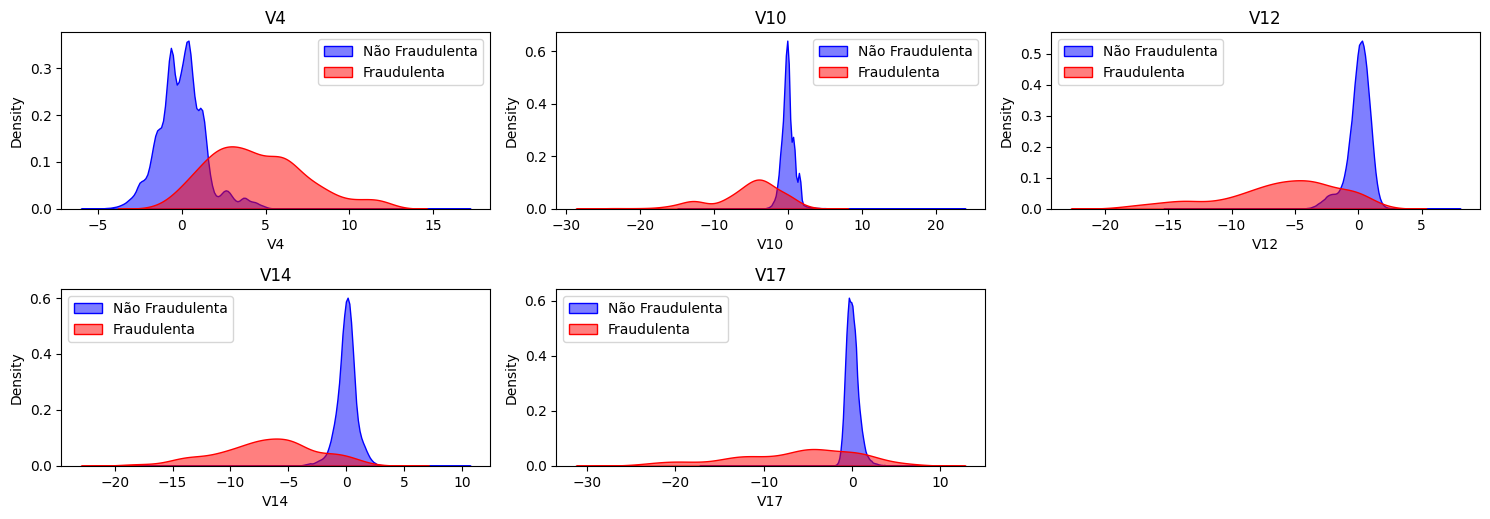

In [10]:
# Criar os gráficos KDE para cada variável
plt.figure(figsize=(15, 10))
for i, coluna in enumerate(features_relevantes, 1):
    plt.subplot(4, 3, i)
    sns.kdeplot(df[df["Class"] == 0][coluna], label="Não Fraudulenta", fill=True, color="blue", alpha=0.5)
    sns.kdeplot(df[df["Class"] == 1][coluna], label="Fraudulenta", fill=True, color="red", alpha=0.5)
    plt.title(coluna)
    plt.legend()

plt.tight_layout()
plt.show()